## kagglehub dataset import
https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017/data

### results

In [30]:
import kagglehub
import os
import pandas as pd
import shutil

# import data with kagglehub
path = kagglehub.dataset_download("martj42/international-football-results-from-1872-to-2017")
print(path)
print(os.listdir(path))

# copy the freshly downloaded files into your project's data/raw folder
raw_dir = "data/raw"
os.makedirs(raw_dir, exist_ok=True)
for fname in ["results.csv", "shootouts.csv"]:
    shutil.copy(os.path.join(path, fname), os.path.join(raw_dir, fname))

C:\Users\ARW\.cache\kagglehub\datasets\martj42\international-football-results-from-1872-to-2017\versions\129
['former_names.csv', 'goalscorers.csv', 'results.csv', 'shootouts.csv']


In [39]:
df_results = pd.read_csv(os.path.join(path, "results.csv"))
df_results = df_results[df_results["date"] >= "1993-01-01"]
df_results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
18708,1993-01-01,Ghana,Mali,1.0,1.0,Friendly,Libreville,Gabon,True
18709,1993-01-02,Gabon,Burkina Faso,1.0,1.0,Friendly,Libreville,Gabon,False
18710,1993-01-02,Kuwait,Lebanon,2.0,0.0,Friendly,Kuwait City,Kuwait,False
18711,1993-01-03,Burkina Faso,Mali,1.0,0.0,Friendly,Libreville,Gabon,True
18712,1993-01-03,Gabon,Ghana,2.0,3.0,Friendly,Libreville,Gabon,False


### shootouts

In [40]:
df_shootouts = pd.read_csv(os.path.join(path, "shootouts.csv"))
df_shootouts.head()

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN


### analysis

In [41]:
df_results["tournament"].value_counts().head(50)

tournament
Friendly                                 10211
FIFA World Cup qualification              6821
UEFA Euro qualification                   1991
African Cup of Nations qualification      1745
UEFA Nations League                        658
AFC Asian Cup qualification                613
African Cup of Nations                     606
FIFA World Cup                             589
CFU Caribbean Cup qualification            453
CONCACAF Nations League                    422
Gold Cup                                   404
CECAFA Cup                                 383
Island Games                               368
COSAFA Cup                                 354
Copa América                               352
UEFA Euro                                  308
AFF Championship                           291
AFC Asian Cup                              282
Gulf Cup                                   234
CFU Caribbean Cup                          187
SAFF Cup                                   162
UN

In [42]:
sorted(df_results["tournament"].unique())

['ABCS Tournament',
 'AFC Asian Cup',
 'AFC Asian Cup qualification',
 'AFC Challenge Cup',
 'AFC Challenge Cup qualification',
 'AFC Solidarity Cup',
 'AFF Championship',
 'AFF Championship qualification',
 'ASEAN Championship',
 'ASEAN Championship qualification',
 'African Cup of Nations',
 'African Cup of Nations qualification',
 'Afro-Asian Games',
 'Al Ain International Cup',
 'Amílcar Cabral Cup',
 'Arab Cup',
 'Arab Cup qualification',
 'Asian Games',
 'Atlantic Heritage Cup',
 'Baltic Cup',
 'Benedikt Fontana Cup',
 'CAFA Nations Cup',
 'CECAFA Cup',
 'CFU Caribbean Cup',
 'CFU Caribbean Cup qualification',
 'CONCACAF Nations League',
 'CONCACAF Nations League qualification',
 'CONCACAF Series',
 'CONIFA Africa Football Cup',
 'CONIFA Asia Cup',
 'CONIFA European Football Cup',
 'CONIFA South America Football Cup',
 'CONIFA World Cup qualification',
 'CONIFA World Football Cup',
 'CONIFA World Football Cup qualification',
 'CONMEBOL–UEFA Cup of Champions',
 'COSAFA Cup',
 'COS

In [43]:
df_results["tournament"].nunique()

142

In [44]:
df_shootouts.head()

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN


## build target variable

In [4]:
# convert to home score results
import numpy as np

df_results["result"] = np.where(df_results["home_score"] > df_results["away_score"], 2,   # home win
               np.where(df_results["home_score"] == df_results["away_score"], 1,  # draw
                0)) # home loss
print(df_results["result"].value_counts(normalize=True).mul(100).round(2)) # percentage of each result


result
2    48.99
0    28.27
1    22.74
Name: proportion, dtype: float64


In [5]:
# sorted chronologically

df_results["date"] = pd.to_datetime(df_results["date"])
df_results = df_results.sort_values("date").reset_index(drop=True)
df_results[["date","home_team","away_team", "result"]].head()

,date,home_team,away_team,result
0,1872-11-30,Scotland,England,1
1,1873-03-08,England,Scotland,2
2,1874-03-07,Scotland,England,2
3,1875-03-06,England,Scotland,1
4,1876-03-04,Scotland,England,2


In [6]:
print(df_results["date"].min())
print(df_results["date"].max())

1872-11-30 00:00:00
2026-07-04 00:00:00


## elo calculation

We first calculate the ELO ratings from the kaggle dataset, using FIFA's SUM system based on match importance factor, elo scores before match, and resultant vs expected elo scores. In the end we want something like:

| date       | home_team | away_team | home_elo | away_elo | result |
| ---------- | --------- | --------- | -------- | -------- | ------ |
| 1950-07-16 | Brazil    | Uruguay   | 1832     | 1798     | loss   |


references: 
- https://digitalhub.fifa.com/m/f99da4f73212220/original/edbm045h0udbwkqew35a-pdf.pdf
- https://fifarankingcalculator.com/
- https://worldfootballrankings.com/methodology

In [7]:
# simple model first
INITIAL_ELO = 1500
from collections import defaultdict
ratings = defaultdict(lambda: 1500)
ratings["England"]

1500

Expected elo score:
$$E_A = 1 / {1+10^{(R_B-R_A)/400}}$$
$$E_B = 1 - E_A$$

Actual score: win=1, draw=0.5, loss=0.

Updated elo score:
$$R_A′=R_A + K (S_A − E_A)$$
$$R_B′=R_B + K (S_B - E_B)$$

In [8]:
K = 30 # initial K-factor
home_elos = [] # containers
away_elos = []

# iterate through each match
for _, row in df_results.iterrows():
    home = row["home_team"]
    away = row["away_team"]

    # calculate current ratings for home and away teams RA, RB
    home_rating = ratings[home]
    away_rating = ratings[away]

    # store PRE-MATCH ratings
    home_elos.append(home_rating)
    away_elos.append(away_rating)

    # apply formula to calculate EA, EB
    expected_home = 1 / (1 + 10 ** ((away_rating - home_rating) / 400))
    expected_away = 1 - expected_home

    # calculate actual result SA, SB
    if row["home_score"] > row["away_score"]:
        actual_home = 1
        actual_away = 0

    elif row["home_score"] < row["away_score"]:
        actual_home = 0
        actual_away = 1

    else:
        actual_home = 0.5
        actual_away = 0.5

    # updated RA', RB'
    ratings[home] = (home_rating + K * (actual_home - expected_home))
    ratings[away] = (away_rating + K * (actual_away - expected_away))


df_results["home_elo"] = home_elos
df_results["away_elo"] = away_elos

In [9]:
# check tail of the dataframe
df_results[["date", "home_team", "away_team", "home_elo", "away_elo"]].tail(10)

,date,home_team,away_team,home_elo,away_elo
49484,2026-07-01,Belgium,Senegal,1880.484427,1804.304269
49485,2026-07-01,United States,Bosnia and Herzegovina,1824.194038,1641.593444
49486,2026-07-01,England,DR Congo,1950.596723,1692.609252
49487,2026-07-02,Portugal,Croatia,1950.833739,1886.684367
49488,2026-07-02,Switzerland,Algeria,1859.262091,1830.162910
49489,2026-07-02,Spain,Austria,2043.156936,1839.385597
49490,2026-07-03,Argentina,Cape Verde,2063.342018,1636.093667
49491,2026-07-03,Colombia,Ghana,1943.978403,1596.330833
49492,2026-07-03,Australia,Egypt,1800.221343,1769.319790
49493,2026-07-04,Canada,Morocco,1808.743979,1921.006807


## train logistic regression

count    49494.000000
mean        10.171436
std        178.014988
min       -968.952622
25%        -99.444815
50%         10.739584
75%        120.967882
max        941.841335
Name: elo_diff, dtype: float64


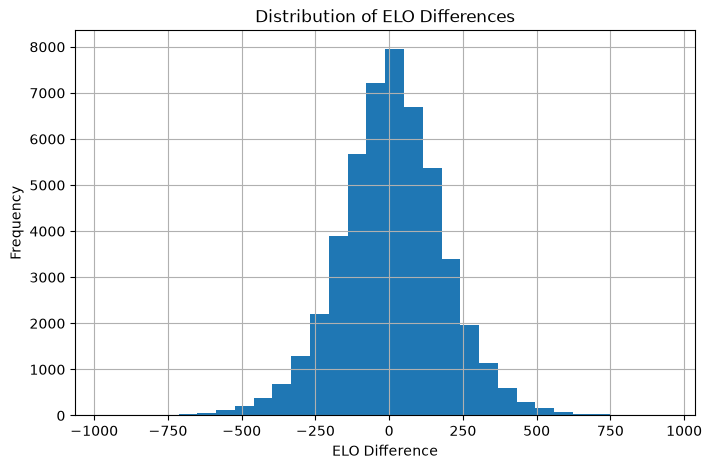

accuracy score = 0.5971563981042654


In [10]:
df_results["elo_diff"] = (df_results["home_elo"] - df_results["away_elo"])
print(df_results["elo_diff"].describe())

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(df_results["elo_diff"], bins=30)
plt.xlabel("ELO Difference")
plt.ylabel("Frequency")
plt.title("Distribution of ELO Differences")
plt.grid(True)
plt.show()
# features
X = df_results[["elo_diff"]]

# targets
y = df_results["result"]

# train/test split:
"""
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)
"""
# time-based split
train = df_results[df_results["date"] < "2020-01-01"]
test = df_results[df_results["date"] >= "2020-01-01"]
X_train = train[["elo_diff"]]
y_train = train["result"]
X_test = test[["elo_diff"]]
y_test = test["result"]

# logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000) # classifier for 3-class problems
model.fit(X_train, y_train) # fit the model to the training data

# get predictions labels, evaluate the model
from sklearn.metrics import accuracy_score
pred = model.predict(X_test)
print(f"accuracy score = {accuracy_score(y_test, pred)}")


In [11]:
# the loss function for logistic regression is the log loss function
from sklearn.metrics import log_loss
# these two metrics are what we compare against later models.
probs = model.predict_proba(X_test)
print(f"log loss = {log_loss(y_test, probs)}")

log loss = 0.8815409191425908


In [12]:
model.predict_proba([[0]])

c:\Users\ARW\anaconda3\envs\prediction\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.2565611 , 0.25728859, 0.48615031]])

In [13]:
model.predict_proba([[300]])

c:\Users\ARW\anaconda3\envs\prediction\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.03896182, 0.1225921 , 0.83844608]])

c:\Users\ARW\anaconda3\envs\prediction\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


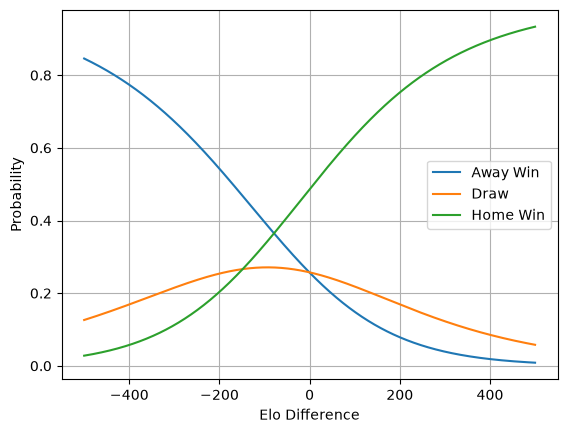

In [14]:
elo_range = np.linspace(-500, 500, 1000).reshape(-1, 1)

probs = model.predict_proba(elo_range)

plt.plot(elo_range, probs[:, 0], label="Away Win")
plt.plot(elo_range, probs[:, 1], label="Draw")
plt.plot(elo_range, probs[:, 2], label="Home Win")

plt.xlabel("Elo Difference")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# save result as csv
df_results.to_csv("data/processed/match_results_with_classical_elo.csv", index=False)

In [16]:
# print top 10 teams by final ELO rating
final_ratings = sorted(ratings.items(), key=lambda x: x[1], reverse=True)
print("Top 10 Teams by Final ELO Rating:")
for team, rating in final_ratings[:10]:
    print(f"{team}: {rating:.2f}")


Top 10 Teams by Final ELO Rating:
Argentina: 2050.70
Spain: 2035.25
France: 2000.29
Brazil: 1970.05
Portugal: 1948.10
England: 1941.14
Colombia: 1932.55
Netherlands: 1930.68
Germany: 1929.64
Morocco: 1916.32


In [17]:
tournament_counts = (
    df_results["tournament"]
    .value_counts()
    .reset_index()
)

tournament_counts.head(50)

,tournament,count
0,Friendly,18388
1,FIFA World Cup qualification,8771
2,UEFA Euro qualification,2824
3,African Cup of Nations qualification,2327
4,FIFA World Cup,1053
5,Copa América,869
6,African Cup of Nations,845
7,AFC Asian Cup qualification,829
8,UEFA Nations League,658
9,CECAFA Cup,620
